In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('./results', exist_ok=True)

with open('./brown_100.txt', 'r') as file_:
    corpus = file_.read()

def write_freqs(list_: list, filename: str) -> None:
    with open(f'./results/{filename}.txt', 'w') as file_:
        file_.write('\n'.join([' '.join(x[0]) + ' | ' + str(x[1]) for x in list_]))

## N-Gram Language Modeling
In the second assignment, you will implement an **n-gram language model** that processes input text to generate, analyze, and calculate the probabilities of sequences of `n` words (n-grams). This model will tokenize text, create n-grams, and compute their frequencies and probabilities, returning the most frequent n-grams in the text.

1. **Tokenization**: Convert the input text into a list of words (tokens).
2. **N-gram Generation**: Create sequences of `n` tokens from the text, treating each sentence independently with the inclusion of start (`<s>`) and end (`</s>`) markers.
3. **Frequency Counting**: Count how many times each n-gram appears in the text.
4. **Probability Calculation**: Compute the probabilities of each n-gram based on its frequency and add alpha smoothing to improve generalization of items.
5. **Most Frequent N-grams**: Return the most frequent n-grams along with their probabilities, helping to identify common patterns in the text.

In [51]:
from collections import Counter, defaultdict # You may import more from collections if needed
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

class NGramModel:
    def __init__(self, text, n, alpha=0.0):
        """
        Initialize the NGramModel with text and the value of n.
        """
        self.text = text
        self.n = n
        self.alpha = alpha  # Alpha value for additive smoothing
        self.ngrams = {}
        self.probabilities = {}
        self.vocab = set()

    def tokenize(self) -> list:
        """
        Tokenize the text into words. 
        Fill in the code to split the text into a list of words.
        """
        sentences = self.text.split('</s>')  # Split the text into sentences based on the end of sentence token
        tokens = []

        for sentence in sentences:
            sentence = sentence.replace('<s>', '').strip()
            if not sentence:
                continue
            words = word_tokenize(sentence.lower())
            tokens.append(words)
            self.vocab.update(words)  # Update the vocabulary  
    
        return tokens

    def generate_ngrams(self, tokens: list) -> list:
        """
        Generate n-grams from the list of tokens.
        Fill in the code to create n-grams.
        Make sure to treat each sentence independently, include the <s> and </s> tokens.
        """

        n_grams = []
        for sentence in tokens:
            sent = ['<s>'] * (self.n - 1) + sentence + ['</s>']    # ensure the start and end of each sentence is marked
            for i in range(len(sent) - self.n + 1):     # ensure we only create full n-grams of length n
                ngram = tuple(sent[i:i+self.n])
                n_grams.append(ngram)
        
        self.ngrams = n_grams
        return self.ngrams

    def count_frequencies(self) -> None:
        """
        Count the frequencies of each n-gram.
        Fill in the code to count n-gram occurrences.
        """
        self.ngrams = Counter(self.ngrams)

    def calculate_probabilities(self) -> None:
        """
        Calculate probabilities of each n-gram based on its frequency. Add alpha smoothing separately.
        """
        self.probabilities = {}
        vocab_size = len(self.vocab)
        if self.n > 1:
            vocab_size += 1  # includes </s> as a possible next token
        
        if self.n == 1:
            total_ngrams = sum(self.ngrams.values())    # sum of all unigram counts
            for ngram, count in self.ngrams.items():
                self.probabilities[ngram] = (count + self.alpha) / (total_ngrams + self.alpha * vocab_size)  
        else:
            context_counts = Counter()  # count and store how many times each context (n-1)-gram appears
            for ngram, count in self.ngrams.items():
                context = ngram[:-1]
                context_counts[context] += count

            for ngram, count in self.ngrams.items():
                context = ngram[:-1]  # context is everything but the last word
                context_count = context_counts[context]  # get how many times the context appears
                self.probabilities[ngram] = (count + self.alpha) / (context_count + self.alpha * vocab_size)

    def most_frequent_ngrams(self, top_n: int = 10) -> list:
        """
        Return the most frequent n-grams and their probabilities.
        """
        most_common = self.ngrams.most_common(top_n)
        return [(ngram, self.probabilities[ngram]) for ngram, _ in most_common]

# Testing the model with an example
text = "This is a simple example to demonstrate how n-grams work in this assignment." #Faster than running the full corpus
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(text, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

# Print the most frequent n-grams
print(model.most_frequent_ngrams(10))

[(('<s>', 'this'), 1.0), (('this', 'is'), 0.5), (('is', 'a'), 1.0), (('a', 'simple'), 1.0), (('simple', 'example'), 1.0), (('example', 'to'), 1.0), (('to', 'demonstrate'), 1.0), (('demonstrate', 'how'), 1.0), (('how', 'n-grams'), 1.0), (('n-grams', 'work'), 1.0)]


[nltk_data] Downloading package punkt to /Users/vlinder/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vlinder/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Unigrams

In this section, we apply the `NGramModel` to our corpus. The model can be configured to generate unigrams, bigrams, or trigrams by adjusting the value of `n`. After tokenizing the text and generating the n-grams, the model counts the occurrences of each n-gram and calculates their probabilities. The most frequent n-grams are then written to an output file.

By adjusting the n-gram size, we can analyze different levels of word dependencies in the text, providing insights into common word sequences and patterns.  

The code below will generate unigrams when the NGramModel is implemented correctly

In [52]:
n = 1  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'unigrams')

### Bigrams
Bigrams allow us to explore word pairs and their relationships, providing insight into common word combinations and phrase structures within the corpus.  
The code below will generate bigrams when the NGramModel is implemented correctly.

In [53]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams')

### Trigrams
Trigrams capture three-word sequences, providing a deeper understanding of longer word dependencies and commonly occurring phrases within the text.  
The code below will generate trigrams when the NGramModel is implemented correctly

In [54]:
n = 3  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'trigrams')

### Smoothing
Below, we generate **bigrams** with **smoothing** applied by setting `n = 2` and including a smoothing parameter `alpha = 1.0`. Smoothing is useful in language models to handle unseen n-grams by assigning a small probability to them. The model tokenizes the text, generates bigrams, counts their frequencies, and calculates smoothed probabilities. The most frequent bigrams are then written to an output file.





In [55]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n, alpha=1.0)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams_smoothed')

### Generating Text
In this example, we generate text using the **bigrams** model by providing a starting **prompt** (e.g., "the jury"). The `generate_text` function creates a sequence of words based on the trained bigram model, starting from the provided prompt and continuing based on the probabilities of the next words.

After tokenizing the corpus, generating bigrams, and calculating their frequencies and probabilities, the model uses these learned probabilities to generate text. The generated output is then written to a file.

Text generation with n-grams helps illustrate how language models can predict word sequences, allowing us to create new sentences that follow similar patterns found in the original text.

In [56]:
def generate_text(model: NGramModel, n: int, prompt: str) -> str:
    tokens = prompt.lower().split()
    generated_tokens = list(tokens)

    while True:
        context = tuple(generated_tokens[-(n-1):]) if n > 1 else ()
        candidates = {
            ngram: prob 
            for ngram, prob in model.probabilities.items() 
            if ngram[:-1] == context
        }
        
        if not candidates:
            break
        
        next_token = max(candidates, key=candidates.get)[-1]

        if next_token == '</s>':
            break
        generated_tokens.append(next_token)

    return ' '.join(generated_tokens)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()
generated_text = generate_text(model, 2, 'the jury')
with open(f'./results/generated_bigrams.txt', 'w') as file_:
    file_.write(generated_text)

tokens = [word for sentence in tokens for word in sentence]  # flatten for the do not edit block in part 3

## Word Vectors
Note: This part of the notebook was originally written for a corpus based on movie reviews from IMDb, based on a Stanford course (https://web.stanford.edu/class/cs224n/). Part of your task is to adapt this portion of the notebook to the corpora used in the previous parts of the assignment: namely, the Brown Corpus and the Indian Language Corpus. You will need to access these corpora from NLTK and perform all functions for both corpora. Note down any updates in the code in your comments.

### Count based W2V
In this section, we use the previously trained **n-gram model** to calculate a **co-occurrence matrix**. A co-occurrence matrix shows how often words appear together within a specific context (in this case, bigrams), providing insights into word relationships in the corpus.

Steps:
1. **Tokenization and N-gram Generation**: We first tokenize the text and generate bigrams using the `NGramModel`.
2. **Vocabulary and Indexing**: The vocabulary is created from the unique tokens, and a word-to-index mapping is established.
3. **Co-occurrence Matrix**: Using the generated n-grams, we compute the co-occurrence matrix, where each entry represents how often two words occur together within the bigrams.

The co-occurrence matrix provides a numerical representation of word relationships, which is useful for tasks like word embeddings, semantic analysis, and understanding word associations.

In [57]:
import nltk
from nltk.corpus import brown
from nltk.corpus import indian
import numpy as np

Brown Corpus

In [ ]:
nltk.download('brown')

# Update from the original notebook:
# Instead of the old example corpus, we now use the Brown Corpus from NLTK.
# We convert the Brown sentences into one text string so we can reuse the Q2 NGramModel.

brown_sentences = brown.sents()
corpus_brown = ' </s> <s> '.join([' '.join(sent) for sent in brown_sentences])

model_brown = NGramModel(corpus_brown, 2)
tokens_brown = model_brown.tokenize()
ngrams_brown = model_brown.generate_ngrams(tokens_brown)

def create_co_matrix(ngrams: list, vocab_size: int, word_to_index: dict) -> np.ndarray:
    """
    Create a co-occurrence matrix from bigrams.

    Each row and column corresponds to a word in the vocabulary.
    If a bigram (w1, w2) appears, we increment the cell [w1, w2].
    """
    co_matrix = np.zeros((vocab_size, vocab_size), dtype=np.int32)

    for w1, w2 in ngrams:
        # only count real words
        if w1 in word_to_index and w2 in word_to_index:
            i = word_to_index[w1]
            j = word_to_index[w2]
            co_matrix[i][j] += 1

    return co_matrix

# tokens returned by the NGramModel are stored per sentence,
# so we flatten them before creating the vocabulary
flat_tokens_brown = [word for sentence in tokens_brown for word in sentence]

# sort so the vocabulary order is stable across runs
vocab_brown = sorted(set(flat_tokens_brown))
vocab_size_brown = len(vocab_brown)

# Create a word-to-index mapping
word_to_index_brown = {word: idx for idx, word in enumerate(vocab_brown)}

# Generate the co-occurrence matrix
co_matrix_brown = create_co_matrix(ngrams_brown, vocab_size_brown, word_to_index_brown)

# print some diagnostics
print("Brown co-occurrence matrix shape:", co_matrix_brown.shape)
print("Brown total co-occurrences:", np.sum(co_matrix_brown))
print("Brown non-zero entries:", np.count_nonzero(co_matrix_brown))



[nltk_data] Downloading package brown to /Users/vlinder/nltk_data...
[nltk_data]   Package brown is already up-to-date!


Brown co-occurrence matrix shape: (47567, 47567)
Brown total co-occurrences: 1116446
Brown non-zero entries: 424096


In [ ]:
def check_co_occurrence(word1, word2, co_matrix, word_to_index):
    """
    Print the co-occurrence count for a specific word pair.
    """
    if word1 not in word_to_index or word2 not in word_to_index:
        print(f"One or both words '{word1}' and '{word2}' are not in the vocabulary.")
        return

    index1 = word_to_index[word1]
    index2 = word_to_index[word2]

    co_count = co_matrix[index1][index2]
    print(f"Co-occurrence count for '{word1}' and '{word2}': {co_count}")

# example checks for Brown
check_co_occurrence('the', 'jury', co_matrix_brown, word_to_index_brown)
check_co_occurrence('the', 'man', co_matrix_brown, word_to_index_brown)
check_co_occurrence('the', 'oompaloompa', co_matrix_brown, word_to_index_brown)

# The pair ('the', 'jury') has a much lower count, but is still meaningful.
# It reflects more specific contexts, likely related to legal or courtroom
# discussions in the Brown corpus. This shows how co-occurrence captures
# topic-specific relationships between words.

# The pair ('the', 'man') has a very high co-occurrence count, which is expected
# because both words are extremely common in English text. "The" is the most frequent
# determiner, and "man" is a common noun in narrative and descriptive writing,
# so they often appear together in phrases like "the man".

# The word 'oompaloompa' does not appear in the vocabulary, which makes sense
# because the Brown corpus consists of real-world texts and does not include
# fictional or rare terms like this. This highlights that the co-occurrence
# matrix only reflects patterns present in the actual corpus.


Co-occurrence count for 'the' and 'jury': 36
Co-occurrence count for 'the' and 'man': 214
One or both words 'the' and 'oompaloompa' are not in the vocabulary.


Indian corpus

In [60]:
nltk.download('indian')

# Update from the original notebook:
# We adapt the code to the Indian Language Corpus from NLTK.
# We again convert the corpus into one text string so we can reuse the Q2 NGramModel.

indian_sentences = indian.sents()
corpus_indian = ' </s> <s> '.join([' '.join(sent) for sent in indian_sentences])

model_indian = NGramModel(corpus_indian, 2)
tokens_indian = model_indian.tokenize()
ngrams_indian = model_indian.generate_ngrams(tokens_indian)

# tokens returned by the NGramModel are stored per sentence,
# so we flatten them before creating the vocabulary
flat_tokens_indian = [word for sentence in tokens_indian for word in sentence]

# sort so the vocabulary order is stable across runs
vocab_indian = sorted(set(flat_tokens_indian))
vocab_size_indian = len(vocab_indian)

# Create a word-to-index mapping
word_to_index_indian = {word: idx for idx, word in enumerate(vocab_indian)}

# Generate the co-occurrence matrix
co_matrix_indian = create_co_matrix(ngrams_indian, vocab_size_indian, word_to_index_indian)

# print some diagnostics
print("Indian co-occurrence matrix shape:", co_matrix_indian.shape)
print("Indian total co-occurrences:", np.sum(co_matrix_indian))
print("Indian non-zero entries:", np.count_nonzero(co_matrix_indian))

# example checks for Indian
check_co_occurrence('भारत', 'का', co_matrix_indian, word_to_index_indian)
check_co_occurrence('গ্রাম', 'the', co_matrix_indian, word_to_index_indian)
check_co_occurrence('के', 'लिए', co_matrix_indian, word_to_index_indian)

# The pair ('भारत', 'का') has a relatively low co-occurrence count.
# While both words are common in Hindi, they do not always appear directly
# next to each other as a bigram. This shows that even frequent words may
# not have high co-occurrence if they are not consistently adjacent.

# The pair ('গ্রাম', 'the') does not exist in the vocabulary.
# This is because the Indian corpus contains non-English text, and after
# preprocessing, English words like "the" are not present. This highlights
# that co-occurrence analysis is limited to the language(s) actually present
# in the corpus.

# The pair ('के', 'लिए') has a high co-occurrence count.
# This is expected because it forms a very common Hindi phrase meaning "for".
# Since these function words frequently appear together, they produce a strong
# signal in the co-occurrence matrix.



[nltk_data] Downloading package indian to /Users/vlinder/nltk_data...
[nltk_data]   Package indian is already up-to-date!


Indian co-occurrence matrix shape: (16075, 16075)
Indian total co-occurrences: 45576
Indian non-zero entries: 36568
Co-occurrence count for 'भारत' and 'का': 1
One or both words 'গ্রাম' and 'the' are not in the vocabulary.
Co-occurrence count for 'के' and 'लिए': 56


In this part, we reduce the dimensionality of the **co-occurrence matrix** using **Singular Value Decomposition (SVD)**. This technique helps in extracting the most important features from the matrix, making it easier to visualize and interpret the relationships between words.

Steps:
1. **Singular Value Decomposition (SVD)**: The co-occurrence matrix is decomposed into three matrices: \( M = U \cdot \Sigma \cdot V^T \).
2. **Dimensionality Reduction**: We retain only the top `k` components (default is 2) from the SVD, effectively reducing the dimensionality of the matrix.
3. **Reduced Matrix**: The reduced matrix retains the most important semantic information and can be used for tasks such as **word embedding visualization** or **semantic similarity analysis**.

Dimensionality reduction allows us to capture the essence of word relationships in fewer dimensions, making it more efficient to process and visualize the data.

In [ ]:
# def reduce_to_k_dim(M, k=2):
#     """
#     Reduce a co-occurrence matrix to k dimensions using Singular Value Decomposition (SVD).
    
#     We decompose the matrix M into U, S, and V^T and keep only the top k components.
#     This allows us to represent each word in a lower-dimensional space.
#     """
#     # SVD
#     U, S, V_T = np.linalg.svd(M, full_matrices=False)
    
#     # keep only the top k dimensions
#     U_reduced = U[:, :k]
#     S_reduced = np.diag(S[:k])
    
#     # compute reduced matrix
#     M_reduced = np.dot(U_reduced, S_reduced)
    
#     return M_reduced




# We replaced full SVD with truncated sparse SVD (scipy.sparse.linalg.svds) for computational efficiency. 
# This still performs SVD-based dimensionality reduction, 
# but computes only the top k singular components needed for the 2D embeddings.

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

def reduce_to_k_dim(M, k=2):
    """
    Reduce a co-occurrence matrix to k dimensions using truncated SVD.

    This is faster than full SVD for large sparse matrices because it only
    computes the top k singular values/vectors instead of the full decomposition.
    """
    # convert to sparse format for efficiency
    M_sparse = csr_matrix(M)

    # compute top k singular values/vectors
    U, S, Vt = svds(M_sparse, k=k)

    # svds returns singular values in ascending order, so reverse them
    U = U[:, ::-1]
    S = S[::-1]

    # create reduced matrix
    M_reduced = U @ np.diag(S)

    return M_reduced

In [62]:
M_reduced_brown = reduce_to_k_dim(co_matrix_brown, k=2)
print(M_reduced_brown.shape)

M_reduced_indian = reduce_to_k_dim(co_matrix_indian, k=2)
print(M_reduced_indian.shape)

(47567, 2)
(16075, 2)


In this final part, we visualize the reduced word embeddings in **2D space**. After reducing the dimensionality of the co-occurrence matrix using SVD, we plot the embeddings for each word to observe their relationships in a low-dimensional space.

Steps:
1. **Plotting the Embeddings**: Each word from the vocabulary is plotted based on its 2D coordinates from the reduced matrix.
2. **Visualization**: The scatter plot allows us to see how words cluster together or relate to each other based on co-occurrences in the text. Words with similar contexts should appear closer to each other in the plot.
3. **Interpretation**: By looking at the 2D plot, we can analyze word similarities, relationships, and clusters formed by words that often occur together.

This visualization is a useful tool for understanding the structure of word embeddings and the relationships between words in the corpus.







In [64]:
def plot_embeddings(M_reduced, word_to_index, words, title, label_map=None):
    """
    Plot selected word embeddings in 2D space.

    M_reduced: reduced matrix where each row is a 2D word vector
    word_to_index: dictionary mapping each word to its row index
    words: list of words to plot
    title: title for the plot
    """
    plt.figure(figsize=(10, 8))

    for word in words:
        if word in word_to_index:
            idx = word_to_index[word]
            x = M_reduced[idx, 0]
            y = M_reduced[idx, 1]

            label = label_map[word] if label_map and word in label_map else word

            plt.scatter(x, y)
            plt.text(x, y, label, fontsize=10)
        else:
            print(f"'{word}' not in vocabulary, skipping.")

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title(title)
    plt.grid(True)
    plt.show()

#note: word list needs to be adjusted to each new corpus with an explanation of why you choose to plot the words you do

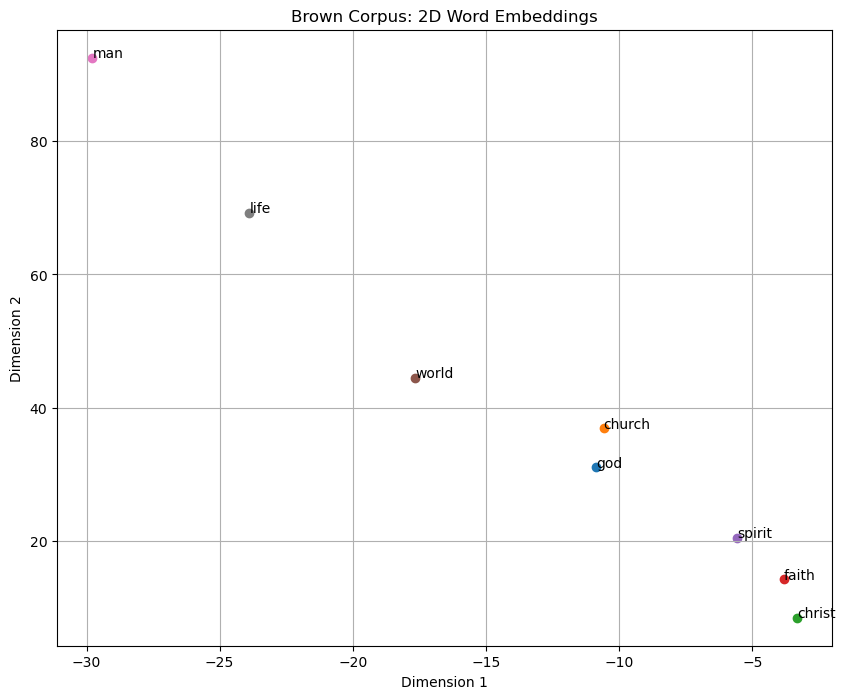

In [65]:
# We selected these words based on their frequency in the Brown religion corpus.
# Words such as "god", "church", "christ", "faith", and "spirit" are central to
# religious discourse and are likely to appear in similar contexts, making them
# good candidates for observing semantic clustering in the embedding space.
#
# We also included more general words like "world", "man", and "life" to compare
# whether broader concepts are positioned differently from more domain-specific
# religious terms.

words_brown = words_brown = ['god', 'church', 'christ', 'faith', 'spirit', 'world', 'man', 'life']

plot_embeddings(M_reduced_brown, word_to_index_brown, words_brown, "Brown Corpus: 2D Word Embeddings")

Interpretation:
In the Brown religion corpus, we observe that several explicitly religious terms such as "god", "church", "christ", "faith", and "spirit" are positioned relatively close to each other in the 2D embedding space. This suggests that these words frequently occur in similar contexts and that the co-occurrence-based word vectors successfully capture domain-specific semantic relationships.

In contrast, more general words such as "man", "life", and "world" are located further away from this cluster. This likely reflects their broader usage across different contexts, not limited to religious discourse. For example, "man" and "life" appear in a wide variety of situations, which results in more dispersed representations.

Overall, the plot demonstrates that words with similar meanings or contextual usage tend to cluster together, supporting the distributional hypothesis, although some distortion is expected due to the reduction to only two dimensions.

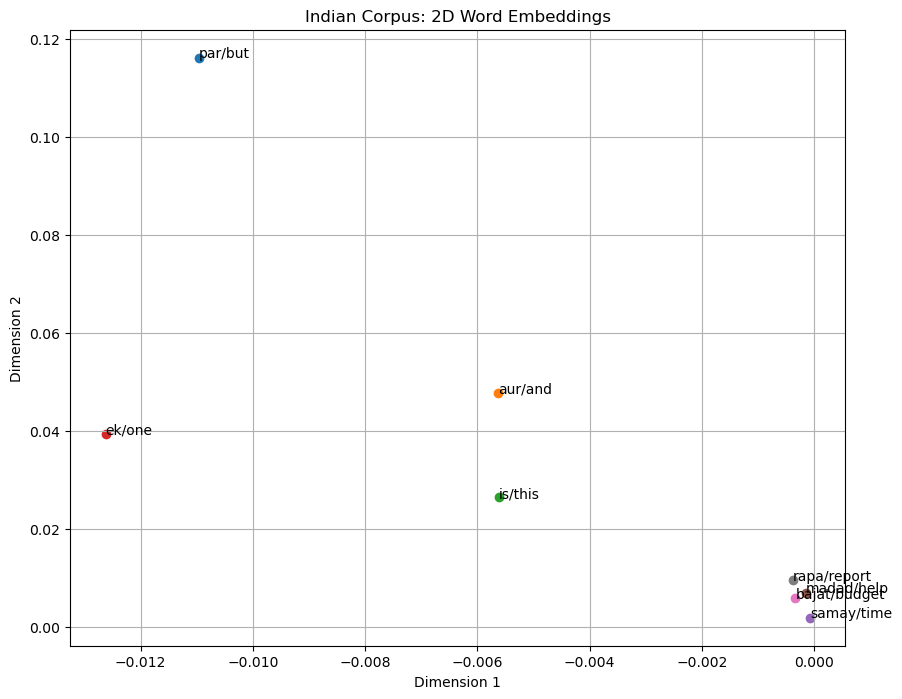

In [130]:
# We selected these words based on their frequency in the Hindi corpus.
# Common function words such as "पर", "और", "इस", and "एक" are expected to appear
# in many different contexts, while content words like "समय" (time), "मदद" (help),
# "बजट" (budget), and "रपट" (report) represent more specific topics.
#
# This combination allows us to examine whether high-frequency function words
# behave differently from content words, and whether words with related meanings
# appear closer together in the embedding space.

words_indian = ['पर', 'और', 'इस', 'एक', 'समय', 'मदद', 'बजट', 'रपट']

label_map_indian = {
    'पर': 'par/but',
    'और': 'aur/and',
    'इस': 'is/this',
    'एक': 'ek/one',
    'समय': 'samay/time',
    'मदद': 'madad/help',
    'बजट': 'bajat/budget',
    'रपट': 'rapa/report'
}

plot_embeddings(M_reduced_indian, word_to_index_indian, words_indian, "Indian Corpus: 2D Word Embeddings", label_map=label_map_indian)

Interpretation:
In the Indian corpus, the visualisation shows a clear separation between high-frequency function words and more content-specific words. Words such as "par", "aur", "is", and "ek", which are common grammatical function words, are distributed more widely across the space, reflecting their use in many different contexts.

In contrast, content words such as "samay" (time), "madad" (help), "bajat" (budget), and "rapat" (report) appear closer together, suggesting that they may occur in more specific or related contexts within the corpus.

The clustering is less pronounced than in the Brown corpus, which may be due to the smaller size of the dataset, the presence of multiple topics, and the fact that some high-frequency words are not semantically specific (we had a little more trouble picking the Indian words, due to our limited knowledge of the Indian languages). Additionally, reducing the data to two dimensions introduces some distortion, which can make patterns harder to interpret.

Overall, the plot still reflects the distributional hypothesis, as words that share similar contextual usage tend to be located closer together.

## Prediction-Based Word Vectors
In this section, we load pre-trained word vectors using the **GloVe** embeddings from the [Stanford NLP paper on GloVe](https://nlp.stanford.edu/pubs/glove.pdf). The pre-trained embeddings provide rich semantic information about words based on large text corpora, allowing us to represent words as vectors that capture their meaning and relationships.

Steps:
1. **Load GloVe Word Vectors**: We use the GloVe embeddings from the `glove-wiki-gigaword-200` model, which has 200-dimensional vectors for each word.
2. **Vocabulary Matching**: We map the words from our corpus to the GloVe vocabulary and extract the corresponding vectors.
3. **Dimensionality Reduction**: After obtaining the word vectors, we reduce the dimensionality to visualize the embeddings in 2D space, allowing us to explore word relationships visually.

This is an excellent opportunity to explore how pre-trained embeddings like GloVe can be used to improve downstream NLP tasks by providing richer word representations.

In [67]:
# Do not edit
import gensim.downloader as api
import numpy as np
wv_from_bin = api.load("glove-wiki-gigaword-200")
print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))

wv_words = list(wv_from_bin.index_to_key)
unique_tokens = set(tokens)
word2ind = {}
M = []
idx = 0
print('rendering M based on wv')
for w in wv_words:
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass

print('rendering M based on unique_tokens')
for w in unique_tokens:
    if w in wv_words:
        continue
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass
M = np.stack(M)
M_reduced = reduce_to_k_dim(M, k=2)

M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis]

Loaded vocab size 400000
rendering M based on wv
rendering M based on unique_tokens


### Compare plots
What stands out when comparing the two different ways of embedding using the given words?

(Use this to help answer the question in your assignment document).

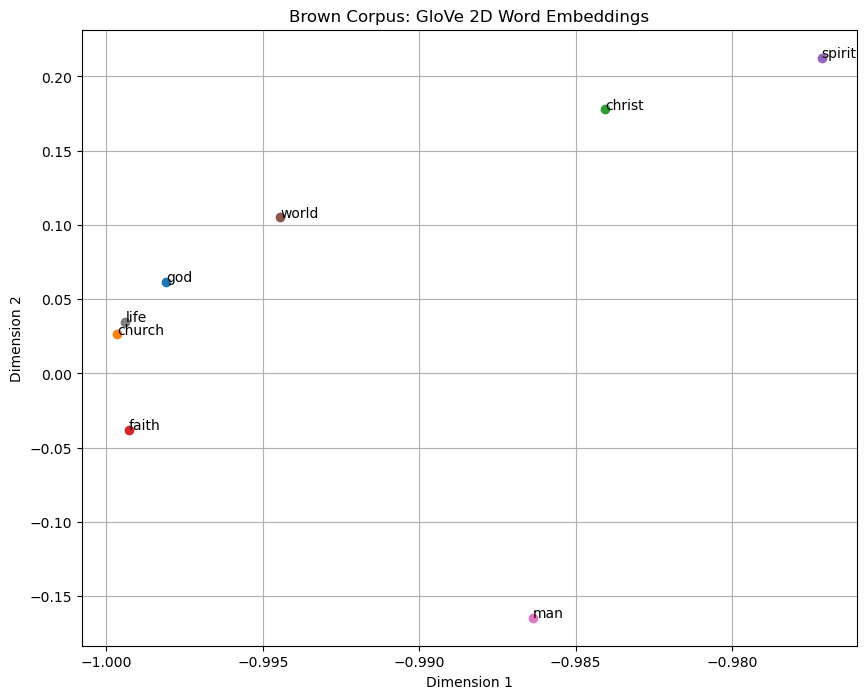

In [72]:
words_brown = ['god', 'church', 'christ', 'faith', 'spirit', 'world', 'man', 'life']

plot_embeddings(M_reduced_normalized, word2ind, words_brown, "Brown Corpus: GloVe 2D Word Embeddings")

'पर' not in vocabulary, skipping.
'इस' not in vocabulary, skipping.
'एक' not in vocabulary, skipping.
'समय' not in vocabulary, skipping.
'मदद' not in vocabulary, skipping.
'बजट' not in vocabulary, skipping.
'रपट' not in vocabulary, skipping.


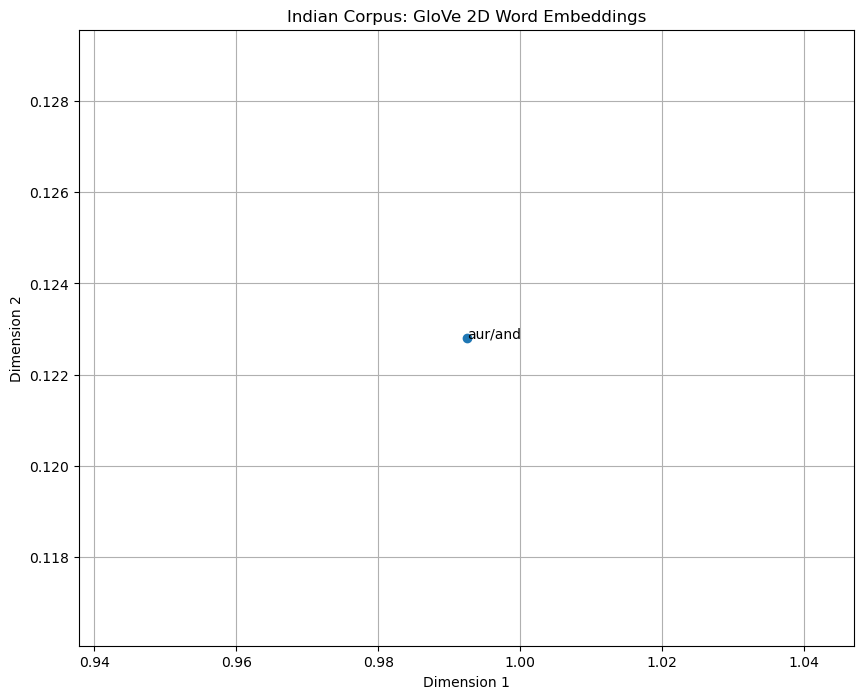

In [131]:
words_indian = ['पर', 'और', 'इस', 'एक', 'समय', 'मदद', 'बजट', 'रपट']

label_map_indian = {
    'पर': 'par/but',
    'और': 'aur/and',
    'इस': 'is/this',
    'एक': 'ek/one',
    'समय': 'samay/time',
    'मदद': 'madad/help',
    'बजट': 'bajat/budget',
    'रपट': 'rapa/report'
}

plot_embeddings(M_reduced_normalized, word2ind, words_indian, "Indian Corpus: GloVe 2D Word Embeddings", label_map=label_map_indian)

Comparing the count-based embeddings with the pretrained GloVe embeddings:

For the Brown corpus, both methods show some degree of semantic structure. In the count-based embeddings, religious words such as "god", "church", "christ", "faith", and "spirit" form a clear cluster, reflecting their frequent co-occurrence in the religion category. However, the overall distribution is more spread out, and distances between words can appear exaggerated due to the sparsity and limited size of the corpus.

In contrast, the GloVe embeddings produce a more compact and smoother representation. While some relationships between words are still visible, the clustering is less sharply defined. This is because GloVe captures global semantic relationships learned from a much larger corpus, rather than only local co-occurrence patterns from the Brown corpus.In the GloVe embeddings, some relationships may appear less intuitive. For example, words like "god" and "christ" are not always closer than "life" and "church". This is because GloVe captures similarity based on shared contexts across a large general corpus, rather than grouping words by specific topics.

For the Indian corpus, the difference is even more pronounced. The count-based embeddings still provide a meaningful representation, with some clustering between content words and separation from function words. However, the GloVe embeddings are largely ineffective, as most Hindi words are not present in the pretrained English-based vocabulary. As a result, very few words can be visualised, and meaningful comparisons are limited.

Overall, count-based embeddings are corpus-specific and can represent any language given sufficient data, but may be less robust. In contrast, pretrained GloVe embeddings provide richer semantic information, but are limited by their training data and may not generalize well to other languages or domains.

### Words with multiple meanings
Polysemes and homonyms are words that have more than one meaning (see [this wiki page](https://en.wikipedia.org/wiki/Polysemy) to learn more about the difference between polysemes and homonyms). Your task is to find a word with at least two different meanings such that the top-10 most similar words (according to cosine similarity) contain related words from both meanings.

For example:
- "leaves" has both the "go_away" and "a_structure_of_a_plant" meanings in the top 10.
- "scoop" has both "handed_waffle_cone" and "lowdown" meanings in the top 10.

You will probably need to try several polysemous or homonymic words before you find one.

Once you discover a word that fits this criterion, state the word and explain the multiple meanings that occur in the top 10. Reflect on why many of the polysemous or homonymic words you tried didn’t work (i.e., why the top-10 most similar words only contain one of the word's meanings).

**Note**: Use the `wv_from_bin.most_similar(word)` function to get the top 10 most similar words. This function ranks all other words in the vocabulary based on their cosine similarity to the given word. For further assistance, you can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html).

In [96]:
## Your code here
print(wv_from_bin.most_similar('bank'))
print(wv_from_bin.most_similar('leaves'))
print(wv_from_bin.most_similar('man'))
print(wv_from_bin.most_similar('bat'))
print(wv_from_bin.most_similar('book'))
print(wv_from_bin.most_similar('spring'))
print(wv_from_bin.most_similar('bear'))
print(wv_from_bin.most_similar('letter'))
print(wv_from_bin.most_similar('ring'))
print(wv_from_bin.most_similar('nail'))



[('banks', 0.7625691294670105), ('banking', 0.6818838119506836), ('central', 0.6283639073371887), ('financial', 0.6166563034057617), ('credit', 0.6049751043319702), ('lending', 0.5980608463287354), ('monetary', 0.5963003039360046), ('bankers', 0.5913101434707642), ('loans', 0.5802940130233765), ('investment', 0.574020266532898)]
[('ends', 0.6128067970275879), ('leaf', 0.6027014851570129), ('stems', 0.5998532176017761), ('takes', 0.5902854800224304), ('leaving', 0.5761634111404419), ('grows', 0.5663396716117859), ('flowers', 0.5600922107696533), ('turns', 0.5536050796508789), ('leave', 0.5496848821640015), ('goes', 0.5434925556182861)]
[('woman', 0.7520086765289307), ('person', 0.6917079091072083), ('another', 0.6866576075553894), ('boy', 0.6848181486129761), ('one', 0.6820703148841858), ('who', 0.6693941354751587), ('he', 0.6683939695358276), ('himself', 0.6633235216140747), ('him', 0.6628837585449219), ('his', 0.6352561116218567)]
[('bats', 0.6917243599891663), ('batting', 0.616058766

A suitable example of a polysemous word is "nail" ("ring and bear were also quite okay)

The word "nail" has at least two meanings:
1. Nail as part of our body, on our fingers and toes
2. Nail as a small metal spike, like the one you use with a hammer

In the top-10 most similar words, we can see evidence of both meanings. Words such as "biter", "remover", "polishes", and "toe" relate to the body definition, while words like "hammer" and "glue" relate more to the construction/tool definition. So the embedding captures more than one sense of the word within a single vector representation.

Many of the other polysemous words I tried, such as "bank", "book", and "spring", returned neighbors connected to only one meaning. This probably happens because one sense is much more frequent in the training data. For the word spring for example, it is much more common to talk about the season than to talk about a water spring. So the single word vector becomes dominated by that meaning. As a result, less frequent senses are not strongly reflected in the top-10 most similar words.

### Synonyms
When considering **Cosine Similarity**, it's often useful to think of **Cosine Distance**, which is simply 1 - Cosine Similarity.

Find three words \( (w_1, w_2, w_3) \) where:
- \(w_1\) and \(w_2\) are **synonyms**.
- \(w_1\) and \(w_3\) are **antonyms**.

However, you need to find a case where **Cosine Distance** \( (w_1, w_3) < \text{Cosine Distance} (w_1, w_2) \). In other words, the antonym is **closer** to the word than its synonym in the vector space.

For example, "happy" (\(w_1\)) may be closer to "sad" (\(w_3\)) than to "cheerful" (\(w_2\)), which is counter-intuitive since we expect synonyms to be closer than antonyms. 

Once you find such an example, provide a possible explanation for why this result may have occurred.

Use the `wv_from_bin.distance(w1, w2)` function to compute the cosine distance between two words. You can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for further assistance.







In [107]:
## Your code here
print(wv_from_bin.distance('big', 'enormous'))
print(wv_from_bin.distance('big', 'small'))

0.41267043
0.35114646


In this example, the antonym small is closer to big than the synonym enormous, which is counter-intuitive. This happens because word embeddings are based on distributional similarity, meaning that words are considered similar if they appear in similar contexts. Words like 'big' and 'small' often appear in very similar contexts (e.g., 'a big house' vs. 'a small house'), so their vectors become close. In contrast, 'enormous' is less frequent and used in more specific contexts, which makes its usage pattern differ from big. This shows that embeddings capture similarity of usage, not true semantic similarity, so antonyms can sometimes appear closer than synonyms.

### Analogies
Word vectors have demonstrated the ability to solve analogies based on their learned semantic relationships. For instance, consider the analogy: 

**"man : grandfather :: woman : x"** 

(Read: man is to grandfather as woman is to x). Using word vectors, we can find the word \(x\) that completes the analogy.

In the example provided, we use the `most_similar` function from the Gensim library. This function identifies words that are most similar to the words in the positive list and most dissimilar to those in the negative list. For analogy solving, it effectively computes:

\[ \text{word}(x) = \text{most similar to} (\text{woman} + \text{grandfather} - \text{man}) \]

The result is the word with the highest cosine similarity to the target vector. You can use this approach to explore various analogies and gain insights into the semantic structure of word vectors.

Refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for more details on the `most_similar` function and how word vectors handle analogy-solving tasks.

In [113]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
print(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))


print("king : queen :: man : x")
print(wv_from_bin.most_similar(positive=['man', 'queen'], negative=['king']))
print()

print("Lisbon : Portugal :: Amsterdam : x")
print(wv_from_bin.most_similar(positive=['amsterdam', 'portugal'], negative=['lisbon']))
print()

print("walking : walked :: leaving : x")
print(wv_from_bin.most_similar(positive=['leaving', 'walked'], negative=['walking']))
print()

[('grandmother', 0.7608445286750793), ('granddaughter', 0.7200808525085449), ('daughter', 0.7168302536010742), ('mother', 0.7151536345481873), ('niece', 0.7005683183670044), ('father', 0.6659887433052063), ('aunt', 0.6623408794403076), ('grandson', 0.6618767380714417), ('grandparents', 0.644661009311676), ('wife', 0.644535481929779)]
king : queen :: man : x
[('woman', 0.7250836491584778), ('girl', 0.5886719226837158), ('she', 0.5709657669067383), ('her', 0.5615236163139343), ('mother', 0.553316056728363), ('person', 0.531572699546814), ('boy', 0.5261016488075256), ('teenager', 0.5241418480873108), ('beautiful', 0.5178191661834717), ('men', 0.515008270740509)]

Lisbon : Portugal :: Amsterdam : x
[('netherlands', 0.7228246927261353), ('holland', 0.5889905691146851), ('dutch', 0.5817781686782837), ('belgium', 0.544658899307251), ('spain', 0.533097505569458), ('denmark', 0.5266199111938477), ('sweden', 0.524466872215271), ('rotterdam', 0.497629314661026), ('germany', 0.49151909351348877), 

By applying vector arithmetic, the model captures patterns such as gender (man → grandfather vs. woman → grandmother), geography (Lisbon → Portugal vs. Amsterdam → Netherlands), and verb transformations (walking → walked vs. leaving → left). These examples demonstrate that similar relationships are encoded consistently across different word pairs. This indicates that word embeddings organize words in a structured space where meaningful relationships correspond to directions in that space.

### Bias in word vectors
a. **Observation**: Consider the results of a word vector model when queried with analogies involving "man", "woman", and "profession". What are the top results returned by the model for each query?

[The model returns different types of top results depending on whether “man” or “woman” is used in the analogy. For the query man + profession − woman, the top results include more general or abstract terms such as reputation, skill, business, and practice. In contrast, for woman + profession − man, the results are more directly related to specific professions, such as teacher, nursing, educator, and physicians. This shows that the model associates “woman” more strongly with certain concrete professions, particularly in fields like education and healthcare, while the results for “man” are less directly tied to specific job titles.]

b. **Analysis**: Do you observe any gender biases in the results? For example, are certain professions more closely associated with "man" or "woman" based on the word vectors? Discuss how word embeddings might perpetuate societal biases present in the training data.

[The results show clear evidence of gender bias in the word embeddings. From the distance comparisons, professions such as engineer, scientist, programmer, and manager are closer to 'man', while professions such as nurse, teacher, receptionist, and doctor are close to 'woman'. This suggests that technical and leadership roles are more strongly associated with men, whereas caregiving and service-oriented roles  are more closely associated with women. The analogy tests reinforce this pattern: for example, the model maps 'man : doctor :: woman : nurse' but 'woman: doctor :: man : dr.', which reflects a stereotypical association between women and nursing. These patterns arise because word embeddings are trained on large text corpora that reflect real-world language use, including historical and societal biases. As a result, embeddings can perpetuate these biases by encoding and reinforcing stereotypical associations between gender and professions, which may then be reproduced in downstream applications.]

c. **Reflection**: How might such biases affect the fairness of machine learning models that use word embeddings? Suggest potential strategies for mitigating gender bias in word vector models.

[Biases in word embeddings can negatively affect the fairness of machine learning models by reinforcing stereotypes and leading to biased decisions. For example, systems used in hiring, recommendation, or search may associate certain professions more strongly with one gender, which can disadvantage individuals and limit equal opportunities. This can result in unfair or discriminatory outcomes, even if the model is not explicitly designed to be biased.

To mitigate these issues, several strategies can be applied. One approach is to use debiasing techniques that remove or reduce gender-related directions in the embedding space. Another is to train models on more balanced and representative datasets that better reflect diversity. Additionally, regular evaluation and auditing for bias can help identify problematic patterns, and fairness-aware algorithms can be used to reduce biased behavior in downstream tasks.]

In [ ]:
# a
print(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
print(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))


[('reputation', 0.5250176787376404), ('professions', 0.5178037881851196), ('skill', 0.49046966433525085), ('skills', 0.49005505442619324), ('ethic', 0.4897659420967102), ('business', 0.487585186958313), ('respected', 0.4859202802181244), ('practice', 0.482104629278183), ('regarded', 0.4778572916984558), ('life', 0.4760662019252777)]

[('professions', 0.5957458019256592), ('practitioner', 0.4988412857055664), ('teaching', 0.48292139172554016), ('nursing', 0.48211804032325745), ('vocation', 0.4788965880870819), ('teacher', 0.47160348296165466), ('practicing', 0.46937811374664307), ('educator', 0.46524327993392944), ('physicians', 0.4628995656967163), ('professionals', 0.4601394236087799)]


In [127]:
# b
professions = [
    'doctor', 'nurse', 'engineer', 'teacher', 'scientist',
    'programmer', 'receptionist', 'manager', 'assistant', 'lawyer'
]

print(f"{'profession':<12} {'dist(man)':<12} {'dist(woman)':<12} closer_to")
for prof in professions:
    d_man = wv_from_bin.distance(prof, 'man')
    d_woman = wv_from_bin.distance(prof, 'woman')
    closer = 'man' if d_man < d_woman else 'woman'
    print(f"{prof:<12} {d_man:<12.4f} {d_woman:<12.4f} {closer}")

profession   dist(man)    dist(woman)  closer_to
doctor       0.5165       0.4706       woman
nurse        0.6424       0.4353       woman
engineer     0.6088       0.7064       man
teacher      0.5772       0.4662       woman
scientist    0.6163       0.6566       man
programmer   0.8295       0.8837       man
receptionist 0.7920       0.5948       woman
manager      0.6295       0.7791       man
assistant    0.6949       0.6998       man
lawyer       0.5601       0.5258       woman


In [129]:
# b
print("man : doctor :: woman : x")
print(wv_from_bin.most_similar(positive=['woman', 'doctor'], negative=['man']))
print()

print("woman : doctor :: man : x")
print(wv_from_bin.most_similar(positive=['man', 'doctor'], negative=['woman']))
print()

print("woman : nurse :: man : x")
print(wv_from_bin.most_similar(positive=['man', 'nurse'], negative=['woman']))
print()



man : doctor :: woman : x
[('nurse', 0.6813318729400635), ('physician', 0.6672453880310059), ('doctors', 0.6173422932624817), ('dentist', 0.5775880217552185), ('surgeon', 0.5691418647766113), ('hospital', 0.564996600151062), ('pregnant', 0.5649074912071228), ('nurses', 0.5590692162513733), ('medical', 0.5542058944702148), ('patient', 0.5518485307693481)]

woman : doctor :: man : x
[('dr.', 0.5486297011375427), ('physician', 0.5327188968658447), ('he', 0.5275285243988037), ('him', 0.5230658054351807), ('himself', 0.5116502642631531), ('medical', 0.5046803951263428), ('his', 0.5044265985488892), ('brother', 0.503484845161438), ('surgeon', 0.5005415678024292), ('mr.', 0.4938008189201355)]

woman : nurse :: man : x
[('doctor', 0.5821742415428162), ('nurses', 0.516983687877655), ('hospital', 0.5130800604820251), ('paramedic', 0.49569931626319885), ('physician', 0.4860961139202118), ('training', 0.4692404866218567), ('sergeant', 0.46916383504867554), ('care', 0.46671396493911743), ('trained'